In [2]:
import pandas as pd

df = pd.read_csv("../data/massua.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
# Dataset ki basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [4]:
# Convert date columns to datetime

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  int64         
 6   Country/Region  10194 non-null  object        
 7   City            10194 non-null  object        
 8   State/Province  10194 non-null  object        
 9   Postal Code     10194 non-null  object        
 10  Division        10194 non-null  object        
 11  Region          10194 non-null  object        
 12  Product ID      10194 non-null  object        
 13  Product Name    10194 non-null  object        
 14  Sales           10194 non-null  float64       
 15  Un

In [5]:
# Basic statistics
df.describe()

,Row ID,Order Date,Ship Date,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-03-13 03:08:26.415538176,2028-10-23 23:20:43.790465024,134468.961154,13.908537,3.791838,9.166451,4.742087
min,1.000000,2024-01-02 00:00:00,2026-06-30 00:00:00,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,2024-09-28 00:00:00,2027-11-09 00:00:00,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,2025-04-06 12:00:00,2028-12-18 00:00:00,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,2025-09-16 00:00:00,2029-11-08 00:00:00,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,2025-12-31 00:00:00,2030-06-28 00:00:00,192314.000000,260.000000,14.000000,130.000000,130.000000
std,2942.898656,NaN,NaN,20231.483007,11.341020,2.228317,6.643740,5.061647


In [6]:
# Check Order Date vs Ship Date difference
df["Delivery_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Delivery Days Stats:")
print(df["Delivery_Days"].describe())

Delivery Days Stats:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Delivery_Days, dtype: float64


In [7]:
# Drop Delivery_Days column (Ship Date unreliable)
df.drop(columns=["Delivery_Days"], inplace=True)

print("Column dropped successfully ✅")
print(df.shape)

Column dropped successfully ✅
(10194, 18)


In [8]:
# Calculate core profitability metrics

# 1. Gross Margin %
df["Gross_Margin_%"] = (df["Gross Profit"] / df["Sales"]) * 100

# 2. Profit per Unit
df["Profit_per_Unit"] = df["Gross Profit"] / df["Units"]

# 3. Cost to Sales Ratio
df["Cost_to_Sales_Ratio"] = (df["Cost"] / df["Sales"]) * 100

# Check for any negative/zero issues
print("Margin Summary:")
print(df["Gross_Margin_%"].describe())

print("\nProfit per Unit Summary:")
print(df["Profit_per_Unit"].describe())

Margin Summary:
count    10194.000000
mean        66.514045
std          6.721012
min          7.692308
25%         65.333333
50%         66.666667
75%         69.444444
max         80.000000
Name: Gross_Margin_%, dtype: float64

Profit per Unit Summary:
count    10194.000000
mean         2.412539
std          0.806007
min          0.250000
25%          2.400000
50%          2.450000
75%          2.490000
max         10.000000
Name: Profit_per_Unit, dtype: float64


In [9]:
# Extract time features from Order Date
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Quarter"] = df["Order Date"].dt.quarter
df["Order_Month_Name"] = df["Order Date"].dt.strftime("%b")

print("Time features added ✅")
print(df[["Order Date", "Order_Year", "Order_Month", "Order_Quarter"]].head())

Time features added ✅
  Order Date  Order_Year  Order_Month  Order_Quarter
0 2024-01-03        2024            1              1
1 2024-01-04        2024            1              1
2 2024-01-04        2024            1              1
3 2024-01-04        2024            1              1
4 2024-01-05        2024            1              1


In [1]:
import pandas as pd

# Load data
df = pd.read_csv("../data/massua.csv")

# Date conversion
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Core metrics
df["Gross_Margin_%"] = (df["Gross Profit"] / df["Sales"]) * 100
df["Profit_per_Unit"] = df["Gross Profit"] / df["Units"]
df["Cost_to_Sales_Ratio"] = (df["Cost"] / df["Sales"]) * 100

# Time features
df["Order_Year"] = df["Order Date"].dt.year
df["Order_Month"] = df["Order Date"].dt.month
df["Order_Quarter"] = df["Order Date"].dt.quarter
df["Order_Month_Name"] = df["Order Date"].dt.strftime("%b")

# Factory mapping
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise"  : "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows"          : "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious"     : "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate"         : "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel"  : "Wicked Choccy's",
    "Laffy Taffy"                        : "Sugar Shack",
    "SweeTARTS"                          : "Sugar Shack",
    "Nerds"                              : "Sugar Shack",
    "Fun Dip"                            : "Sugar Shack",
    "Fizzy Lifting Drinks"               : "Sugar Shack",
    "Everlasting Gobstopper"             : "Secret Factory",
    "Lickable Wallpaper"                 : "Secret Factory",
    "Wonka Gum"                          : "Secret Factory",
    "Hair Toffee"                        : "The Other Factory",
    "Kazookles"                          : "The Other Factory"
}

df["Factory"] = df["Product Name"].map(factory_mapping)

print("✅ Data Loaded Successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

✅ Data Loaded Successfully!
Shape: (10194, 26)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Gross_Margin_%', 'Profit_per_Unit', 'Cost_to_Sales_Ratio', 'Order_Year', 'Order_Month', 'Order_Quarter', 'Order_Month_Name', 'Factory']


In [2]:
product_summary = df.groupby(["Product Name", "Division"], as_index=False).agg({
    "Sales": "sum",
    "Units": "sum",
    "Gross Profit": "sum",
    "Cost": "sum"
})

product_summary["Gross_Margin_%"] = (product_summary["Gross Profit"] / product_summary["Sales"]) * 100
product_summary["Profit_per_Unit"] = product_summary["Gross Profit"] / product_summary["Units"]
product_summary["Cost_to_Sales_Ratio"] = (product_summary["Cost"] / product_summary["Sales"]) * 100

product_summary = product_summary.sort_values(by="Gross Profit", ascending=False)

product_summary.head(10)

,Product Name,Division,Sales,Units,Gross Profit,Cost,Gross_Margin_%,Profit_per_Unit,Cost_to_Sales_Ratio
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,19357.50,8517.30,69.444444,2.50,30.555556
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,18610.20,9874.80,65.333333,2.45,34.666667
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11,35.076923
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,16819.95,6755.00,71.346705,2.49,28.653295
9,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,16593.60,8296.80,66.666667,2.40,33.333333
6,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.000000,10.00,50.000000
14,Wonka Gum,Other,597.50,478,310.70,286.80,52.000000,0.65,48.000000
0,Everlasting Gobstopper,Sugar,130.00,13,104.00,26.00,80.000000,8.00,20.000000
4,Kazookles,Other,1205.75,371,92.75,1113.00,7.692308,0.25,92.307692
3,Hair Toffee,Sugar,76.50,17,59.50,17.00,77.777778,3.50,22.222222


In [3]:
print("Top 5 Products by Sales")
display(product_summary.sort_values(by="Sales", ascending=False).head(5))

print("Top 5 Products by Gross Margin %")
display(product_summary.sort_values(by="Gross_Margin_%", ascending=False).head(5))

print("Bottom 5 Products by Gross Margin %")
display(product_summary.sort_values(by="Gross_Margin_%", ascending=True).head(5))

Top 5 Products by Sales


,Product Name,Division,Sales,Units,Gross Profit,Cost,Gross_Margin_%,Profit_per_Unit,Cost_to_Sales_Ratio
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,18610.20,9874.80,65.333333,2.45,34.666667
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,19357.50,8517.30,69.444444,2.50,30.555556
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,17443.37,9424.38,64.923077,2.11,35.076923
9,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,16593.60,8296.80,66.666667,2.40,33.333333
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,16819.95,6755.00,71.346705,2.49,28.653295


Top 5 Products by Gross Margin %


,Product Name,Division,Sales,Units,Gross Profit,Cost,Gross_Margin_%,Profit_per_Unit,Cost_to_Sales_Ratio
0,Everlasting Gobstopper,Sugar,130.00,13,104.00,26.0,80.000000,8.00,20.000000
3,Hair Toffee,Sugar,76.50,17,59.50,17.0,77.777778,3.50,22.222222
11,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,16819.95,6755.0,71.346705,2.49,28.653295
13,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,19357.50,8517.3,69.444444,2.50,30.555556
9,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,16593.60,8296.8,66.666667,2.40,33.333333


Bottom 5 Products by Gross Margin %


,Product Name,Division,Sales,Units,Gross Profit,Cost,Gross_Margin_%,Profit_per_Unit,Cost_to_Sales_Ratio
4,Kazookles,Other,1205.75,371,92.75,1113.0,7.692308,0.25,92.307692
2,Fun Dip,Sugar,12.00,8,4.80,7.2,40.000000,0.60,60.000000
7,Nerds,Sugar,15.00,10,7.00,8.0,46.666667,0.70,53.333333
8,SweeTARTS,Sugar,61.50,41,28.70,32.8,46.666667,0.70,53.333333
6,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.0,50.000000,10.00,50.000000


C:\Users\chouh\AppData\Local\Temp\ipykernel_27616\1111836656.py:71: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chouh\AppData\Local\Temp\ipykernel_27616\1111836656.py:71: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chouh\AppData\Local\Temp\ipykernel_27616\1111836656.py:71: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\chouh\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\chouh\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\chouh\AppData\Roaming\Python\Python313\site-packages\IPyth

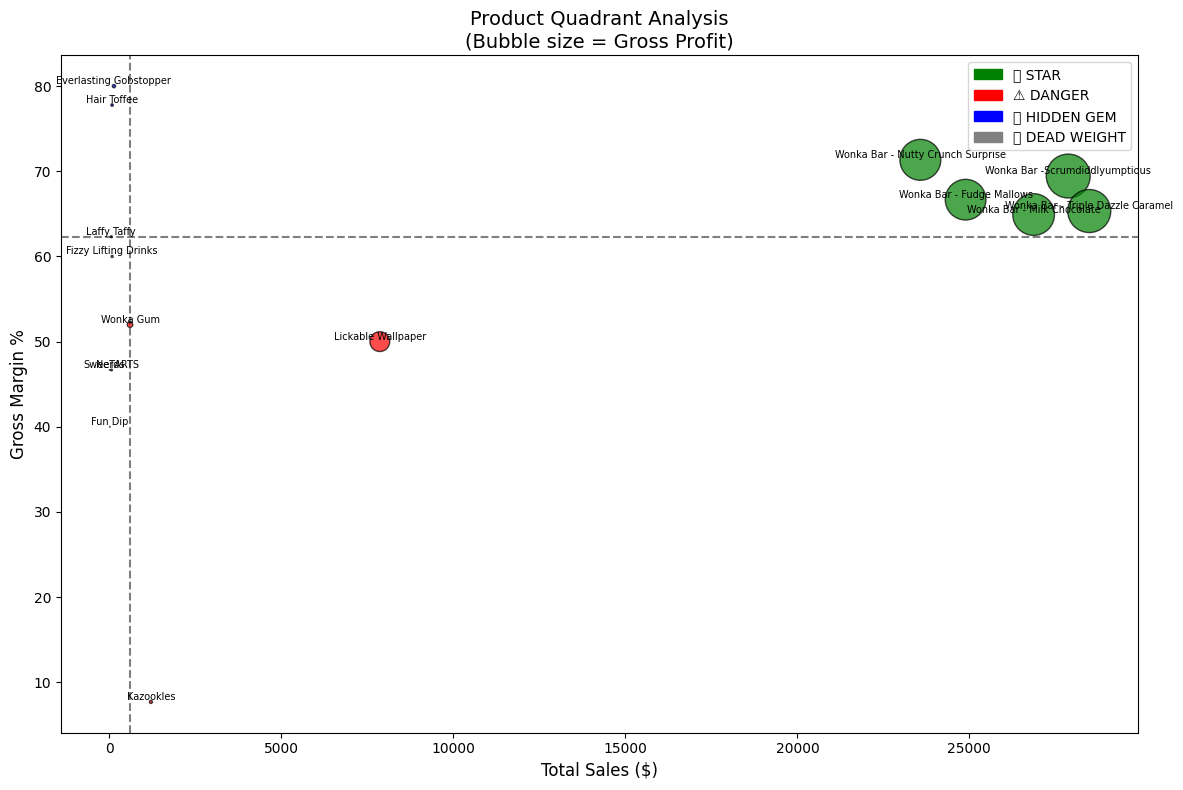


Quadrant Summary:
                         Product Name     Sales  Gross_Margin_%       Quadrant
13     Wonka Bar -Scrumdiddlyumptious  27874.80       69.444444         ⭐ STAR
12  Wonka Bar - Triple Dazzle Caramel  28485.00       65.333333         ⭐ STAR
10         Wonka Bar - Milk Chocolate  26867.75       64.923077         ⭐ STAR
11  Wonka Bar - Nutty Crunch Surprise  23574.95       71.346705         ⭐ STAR
9           Wonka Bar - Fudge Mallows  24890.40       66.666667         ⭐ STAR
6                  Lickable Wallpaper   7860.00       50.000000      ⚠️ DANGER
14                          Wonka Gum    597.50       52.000000      ⚠️ DANGER
0              Everlasting Gobstopper    130.00       80.000000   💎 HIDDEN GEM
4                           Kazookles   1205.75        7.692308      ⚠️ DANGER
3                         Hair Toffee     76.50       77.777778   💎 HIDDEN GEM
1                Fizzy Lifting Drinks     78.75       60.000000  ❌ DEAD WEIGHT
5                         Laffy T

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Thresholds
sales_median = product_summary["Sales"].median()
margin_median = product_summary["Gross_Margin_%"].median()

# Quadrant assign karna
def assign_quadrant(row):
    if row["Sales"] >= sales_median and row["Gross_Margin_%"] >= margin_median:
        return "⭐ STAR"
    elif row["Sales"] >= sales_median and row["Gross_Margin_%"] < margin_median:
        return "⚠️ DANGER"
    elif row["Sales"] < sales_median and row["Gross_Margin_%"] >= margin_median:
        return "💎 HIDDEN GEM"
    else:
        return "❌ DEAD WEIGHT"

product_summary["Quadrant"] = product_summary.apply(assign_quadrant, axis=1)

# Colors
color_map = {
    "⭐ STAR"       : "green",
    "⚠️ DANGER"     : "red",
    "💎 HIDDEN GEM" : "blue",
    "❌ DEAD WEIGHT": "gray"
}

colors = product_summary["Quadrant"].map(color_map)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    product_summary["Sales"],
    product_summary["Gross_Margin_%"],
    c=colors,
    s=product_summary["Gross Profit"] / product_summary["Gross Profit"].max() * 1000,
    alpha=0.7,
    edgecolors="black"
)

# Product labels
for _, row in product_summary.iterrows():
    ax.annotate(
        row["Product Name"],
        (row["Sales"], row["Gross_Margin_%"]),
        fontsize=7,
        ha="center",
        va="bottom"
    )

# Quadrant lines
ax.axvline(x=sales_median, color="black", linestyle="--", alpha=0.5)
ax.axhline(y=margin_median, color="black", linestyle="--", alpha=0.5)

# Labels
ax.set_xlabel("Total Sales ($)", fontsize=12)
ax.set_ylabel("Gross Margin %", fontsize=12)
ax.set_title("Product Quadrant Analysis\n(Bubble size = Gross Profit)", fontsize=14)

# Legend
patches = [
    mpatches.Patch(color="green", label="⭐ STAR"),
    mpatches.Patch(color="red",   label="⚠️ DANGER"),
    mpatches.Patch(color="blue",  label="💎 HIDDEN GEM"),
    mpatches.Patch(color="gray",  label="❌ DEAD WEIGHT")
]
ax.legend(handles=patches, loc="upper right")

plt.tight_layout()
plt.show()

# Print quadrant summary
print("\nQuadrant Summary:")
print(product_summary[["Product Name", "Sales", "Gross_Margin_%", "Quadrant"]])

In [5]:
# Division Level Analysis
division_summary = df.groupby("Division", as_index=False).agg({
    "Sales"       : "sum",
    "Units"       : "sum",
    "Gross Profit": "sum",
    "Cost"        : "sum"
})

division_summary["Gross_Margin_%"] = (division_summary["Gross Profit"] / division_summary["Sales"]) * 100
division_summary["Profit_Contribution_%"] = (division_summary["Gross Profit"] / division_summary["Gross Profit"].sum()) * 100
division_summary["Revenue_Contribution_%"] = (division_summary["Sales"] / division_summary["Sales"].sum()) * 100

division_summary = division_summary.sort_values(by="Gross Profit", ascending=False)

print("Division Summary:")
display(division_summary)

Division Summary:


,Division,Sales,Units,Gross Profit,Cost,Gross_Margin_%,Profit_Contribution_%,Revenue_Contribution_%
0,Chocolate,131692.90,37275,88824.62,42868.28,67.448298,95.057747,92.883008
1,Other,9663.25,1242,4333.45,5329.80,44.844643,4.637543,6.815491
2,Sugar,427.48,137,284.73,142.75,66.606625,0.304710,0.301502


## Division Performance Analysis

This section compares revenue, gross profit, and gross margin across product divisions to identify the strongest and weakest business segments.

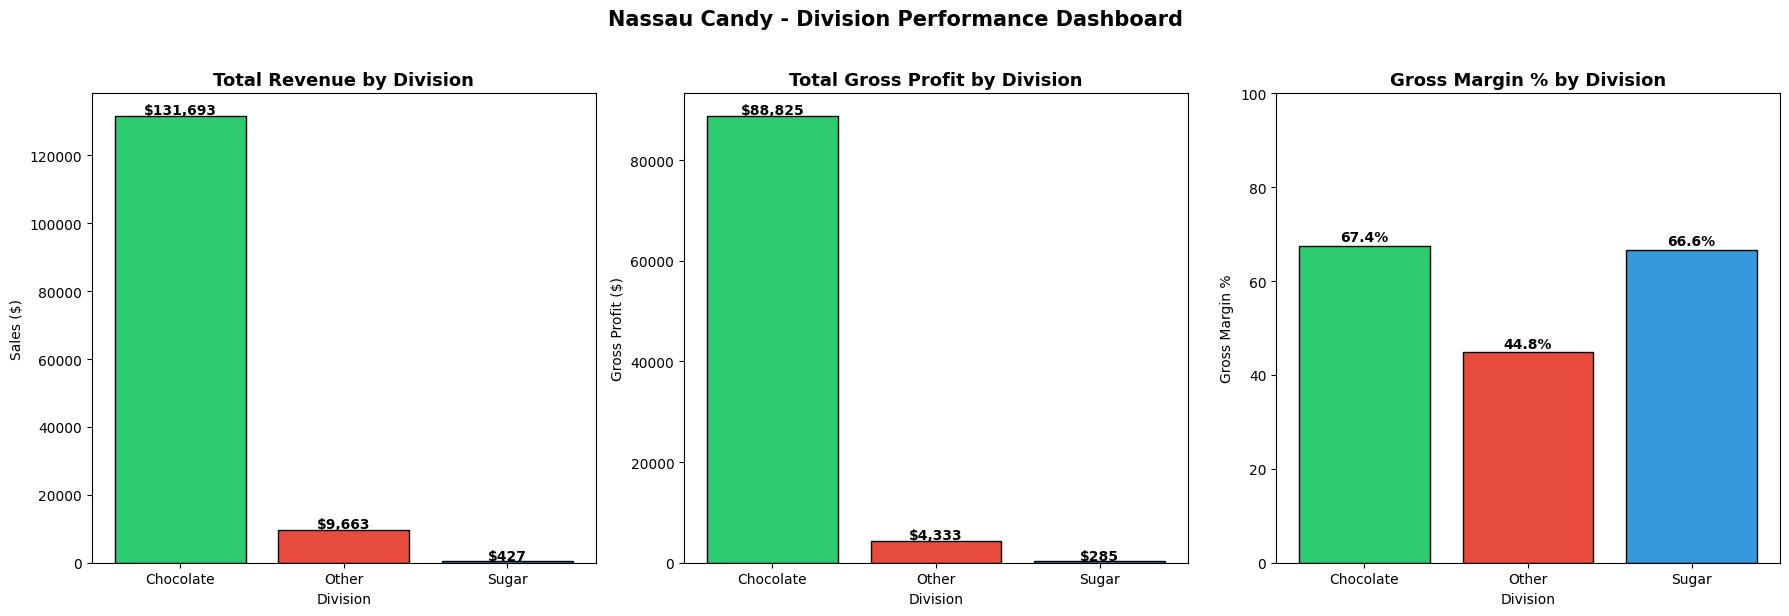

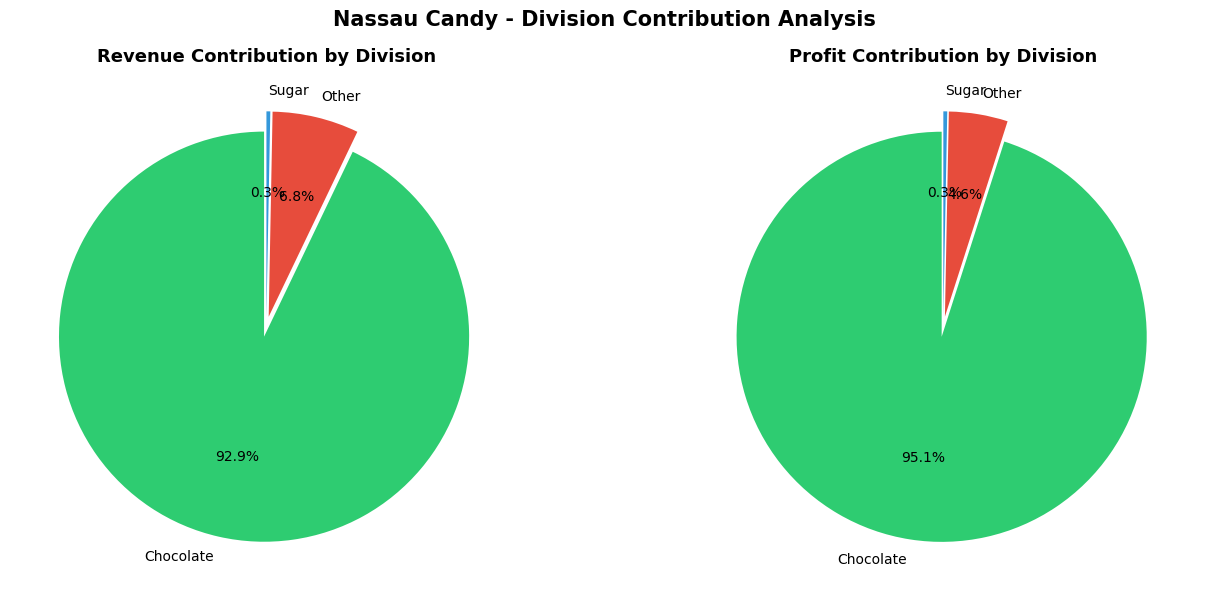

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

divisions = division_summary["Division"]
colors = ["#2ecc71", "#e74c3c", "#3498db"]

# Chart 1: Revenue by Division
axes[0].bar(divisions, division_summary["Sales"], color=colors, edgecolor="black")
axes[0].set_title("Total Revenue by Division", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Division")
axes[0].set_ylabel("Sales ($)")
for i, v in enumerate(division_summary["Sales"]):
    axes[0].text(i, v + 500, f"${v:,.0f}", ha="center", fontweight="bold")

# Chart 2: Gross Profit by Division
axes[1].bar(divisions, division_summary["Gross Profit"], color=colors, edgecolor="black")
axes[1].set_title("Total Gross Profit by Division", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Division")
axes[1].set_ylabel("Gross Profit ($)")
for i, v in enumerate(division_summary["Gross Profit"]):
    axes[1].text(i, v + 300, f"${v:,.0f}", ha="center", fontweight="bold")

# Chart 3: Gross Margin % by Division
axes[2].bar(divisions, division_summary["Gross_Margin_%"], color=colors, edgecolor="black")
axes[2].set_title("Gross Margin % by Division", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Division")
axes[2].set_ylabel("Gross Margin %")
axes[2].set_ylim(0, 100)
for i, v in enumerate(division_summary["Gross_Margin_%"]):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Nassau Candy - Division Performance Dashboard",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Pie Charts
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

# Revenue Pie
axes2[0].pie(
    division_summary["Revenue_Contribution_%"],
    labels=divisions,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=[0.05, 0.05, 0.05]
)
axes2[0].set_title("Revenue Contribution by Division", fontsize=13, fontweight="bold")

# Profit Pie
axes2[1].pie(
    division_summary["Profit_Contribution_%"],
    labels=divisions,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=[0.05, 0.05, 0.05]
)
axes2[1].set_title("Profit Contribution by Division", fontsize=13, fontweight="bold")

plt.suptitle("Nassau Candy - Division Contribution Analysis",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Factory Level Analysis

This section analyzes profitability and cost efficiency across different manufacturing factories to identify which factories produce the most profitable products.

In [7]:
# Factory Level Analysis
factory_summary = df.groupby("Factory", as_index=False).agg({
    "Sales"       : "sum",
    "Units"       : "sum",
    "Gross Profit": "sum",
    "Cost"        : "sum"
})

factory_summary["Gross_Margin_%"] = (factory_summary["Gross Profit"] / factory_summary["Sales"]) * 100
factory_summary["Profit_Contribution_%"] = (factory_summary["Gross Profit"] / factory_summary["Gross Profit"].sum()) * 100
factory_summary["Cost_to_Sales_Ratio"] = (factory_summary["Cost"] / factory_summary["Sales"]) * 100

factory_summary = factory_summary.sort_values(by="Gross Profit", ascending=False)

print("Factory Summary:")
display(factory_summary)

Factory Summary:


,Factory,Sales,Units,Gross Profit,Cost,Gross_Margin_%,Profit_Contribution_%,Cost_to_Sales_Ratio
0,Lot's O' Nuts,76340.15,21412,52771.05,23569.10,69.126207,56.474175,30.873793
4,Wicked Choccy's,55352.75,15863,36053.57,19299.18,65.134198,38.583572,34.865802
1,Secret Factory,8587.50,884,4344.70,4242.80,50.593304,4.649582,49.406696
3,The Other Factory,1282.25,388,152.25,1130.00,11.873660,0.162934,88.126340
2,Sugar Shack,220.98,107,121.23,99.75,54.860168,0.129737,45.139832


## Factory Performance Visualization

This section visualizes total sales, gross profit, and gross margin across factories to compare operational efficiency and profitability.

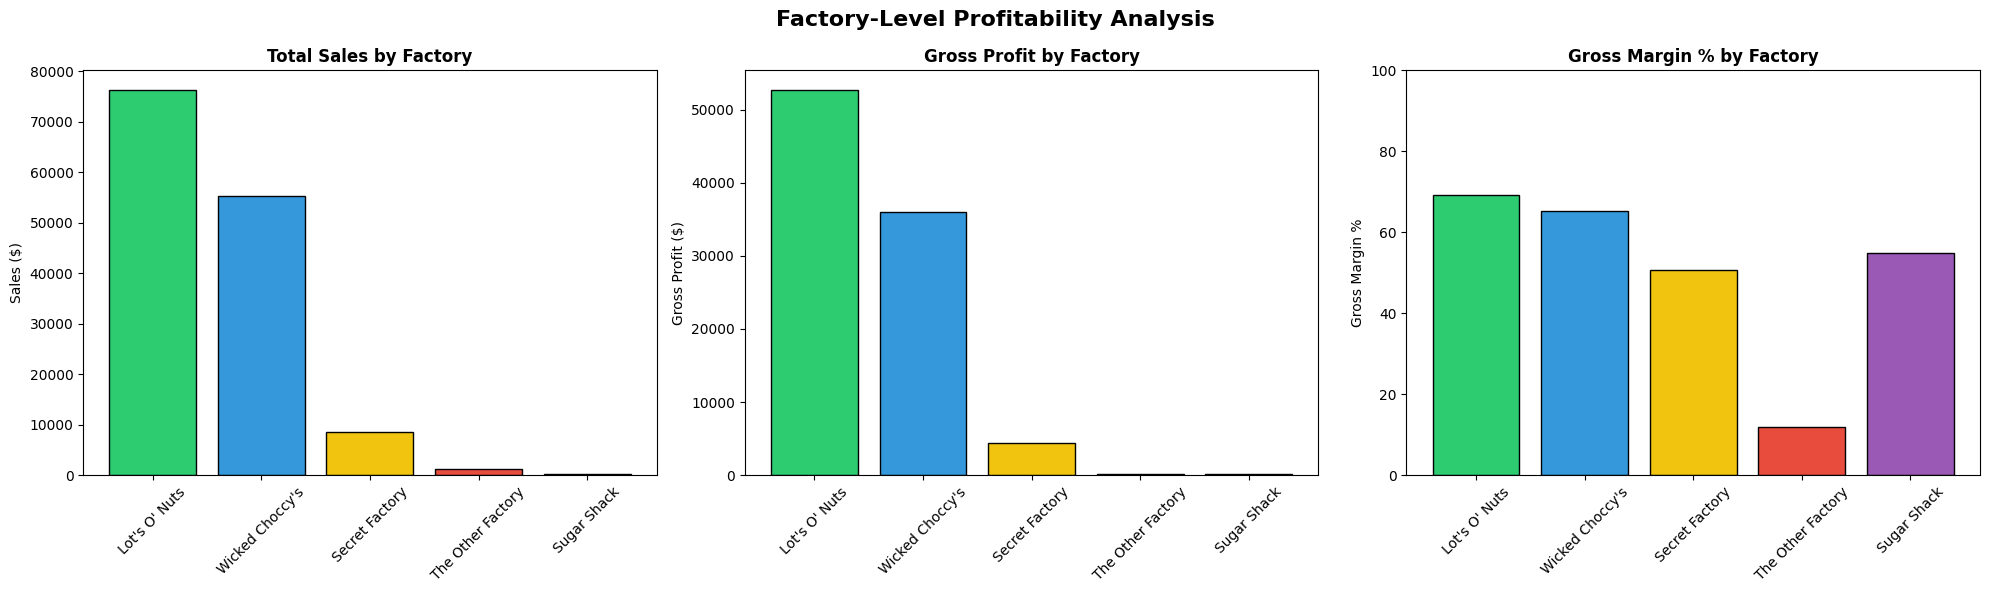

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

factories = factory_summary["Factory"]
colors = ["#2ecc71", "#3498db", "#f1c40f", "#e74c3c", "#9b59b6"]

# Sales chart
axes[0].bar(factories, factory_summary["Sales"], color=colors, edgecolor="black")
axes[0].set_title("Total Sales by Factory", fontweight="bold")
axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis='x', rotation=45)

# Profit chart
axes[1].bar(factories, factory_summary["Gross Profit"], color=colors, edgecolor="black")
axes[1].set_title("Gross Profit by Factory", fontweight="bold")
axes[1].set_ylabel("Gross Profit ($)")
axes[1].tick_params(axis='x', rotation=45)

# Margin chart
axes[2].bar(factories, factory_summary["Gross_Margin_%"], color=colors, edgecolor="black")
axes[2].set_title("Gross Margin % by Factory", fontweight="bold")
axes[2].set_ylabel("Gross Margin %")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle("Factory-Level Profitability Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Profit Concentration Analysis (Pareto)

This section identifies how many products contribute to 80% of total gross profit, helping detect dependency risk in the product portfolio.

In [9]:
# Pareto Analysis - Profit Contribution by Product

pareto_profit = product_summary.sort_values(by="Gross Profit", ascending=False).reset_index(drop=True)

pareto_profit["Cumulative_Profit"] = pareto_profit["Gross Profit"].cumsum()
pareto_profit["Cumulative_Profit_%"] = (
    pareto_profit["Cumulative_Profit"] / pareto_profit["Gross Profit"].sum()
) * 100

pareto_profit["Product_Count"] = pareto_profit.index + 1
pareto_profit["Product_Count_%"] = (
    pareto_profit["Product_Count"] / len(pareto_profit)
) * 100

# Find how many products contribute to 80% of total profit
products_for_80_profit = pareto_profit[pareto_profit["Cumulative_Profit_%"] <= 80].shape[0] + 1

print(f"Total Products: {len(pareto_profit)}")
print(f"Products contributing to 80% of profit: {products_for_80_profit}")

display(
    pareto_profit[[
        "Product Name",
        "Gross Profit",
        "Cumulative_Profit_%",
        "Product_Count_%"
    ]]
)

Total Products: 15
Products contributing to 80% of profit: 5


,Product Name,Gross Profit,Cumulative_Profit_%,Product_Count_%
0,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882,6.666667
1,Wonka Bar - Triple Dazzle Caramel,18610.20,40.632023,13.333333
2,Wonka Bar - Milk Chocolate,17443.37,59.299454,20.000000
3,Wonka Bar - Nutty Crunch Surprise,16819.95,77.299717,26.666667
4,Wonka Bar - Fudge Mallows,16593.60,95.057747,33.333333
5,Lickable Wallpaper,3930.00,99.263528,40.000000
6,Wonka Gum,310.70,99.596031,46.666667
7,Everlasting Gobstopper,104.00,99.707329,53.333333
8,Kazookles,92.75,99.806588,60.000000
9,Hair Toffee,59.50,99.870263,66.666667


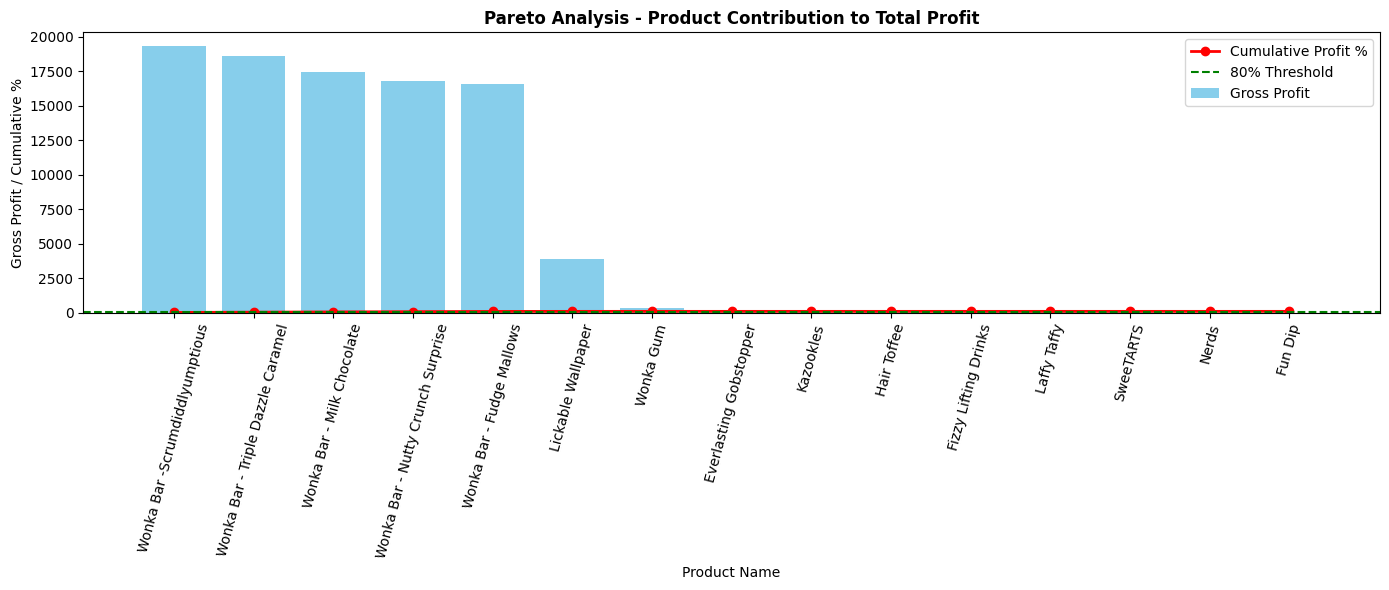

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Bar chart for Gross Profit
plt.bar(pareto_profit["Product Name"], pareto_profit["Gross Profit"], color="skyblue", label="Gross Profit")

# Line chart for cumulative profit %
plt.plot(
    pareto_profit["Product Name"],
    pareto_profit["Cumulative_Profit_%"],
    color="red",
    marker="o",
    linewidth=2,
    label="Cumulative Profit %"
)

# 80% reference line
plt.axhline(y=80, color="green", linestyle="--", label="80% Threshold")

plt.xticks(rotation=75)
plt.ylabel("Gross Profit / Cumulative %")
plt.xlabel("Product Name")
plt.title("Pareto Analysis - Product Contribution to Total Profit", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

## Revenue Concentration Analysis (Pareto)

This section identifies how many products contribute to 80% of total revenue and compares revenue concentration with profit concentration.

In [11]:
# Pareto Analysis - Revenue Contribution by Product

pareto_revenue = product_summary.sort_values(by="Sales", ascending=False).reset_index(drop=True)

pareto_revenue["Cumulative_Revenue"] = pareto_revenue["Sales"].cumsum()
pareto_revenue["Cumulative_Revenue_%"] = (
    pareto_revenue["Cumulative_Revenue"] / pareto_revenue["Sales"].sum()
) * 100

pareto_revenue["Product_Count"] = pareto_revenue.index + 1
pareto_revenue["Product_Count_%"] = (
    pareto_revenue["Product_Count"] / len(pareto_revenue)
) * 100

products_for_80_revenue = pareto_revenue[pareto_revenue["Cumulative_Revenue_%"] <= 80].shape[0] + 1

print(f"Total Products: {len(pareto_revenue)}")
print(f"Products contributing to 80% of revenue: {products_for_80_revenue}")

display(
    pareto_revenue[[
        "Product Name",
        "Sales",
        "Cumulative_Revenue_%",
        "Product_Count_%"
    ]]
)

Total Products: 15
Products contributing to 80% of revenue: 5


,Product Name,Sales,Cumulative_Revenue_%,Product_Count_%
0,Wonka Bar - Triple Dazzle Caramel,28485.00,20.090472,6.666667
1,Wonka Bar -Scrumdiddlyumptious,27874.80,39.750569,13.333333
2,Wonka Bar - Milk Chocolate,26867.75,58.700394,20.000000
3,Wonka Bar - Fudge Mallows,24890.40,76.255595,26.666667
4,Wonka Bar - Nutty Crunch Surprise,23574.95,92.883008,33.333333
5,Lickable Wallpaper,7860.00,98.426666,40.000000
6,Kazookles,1205.75,99.277082,46.666667
7,Wonka Gum,597.50,99.698498,53.333333
8,Everlasting Gobstopper,130.00,99.790187,60.000000
9,Fizzy Lifting Drinks,78.75,99.845730,66.666667


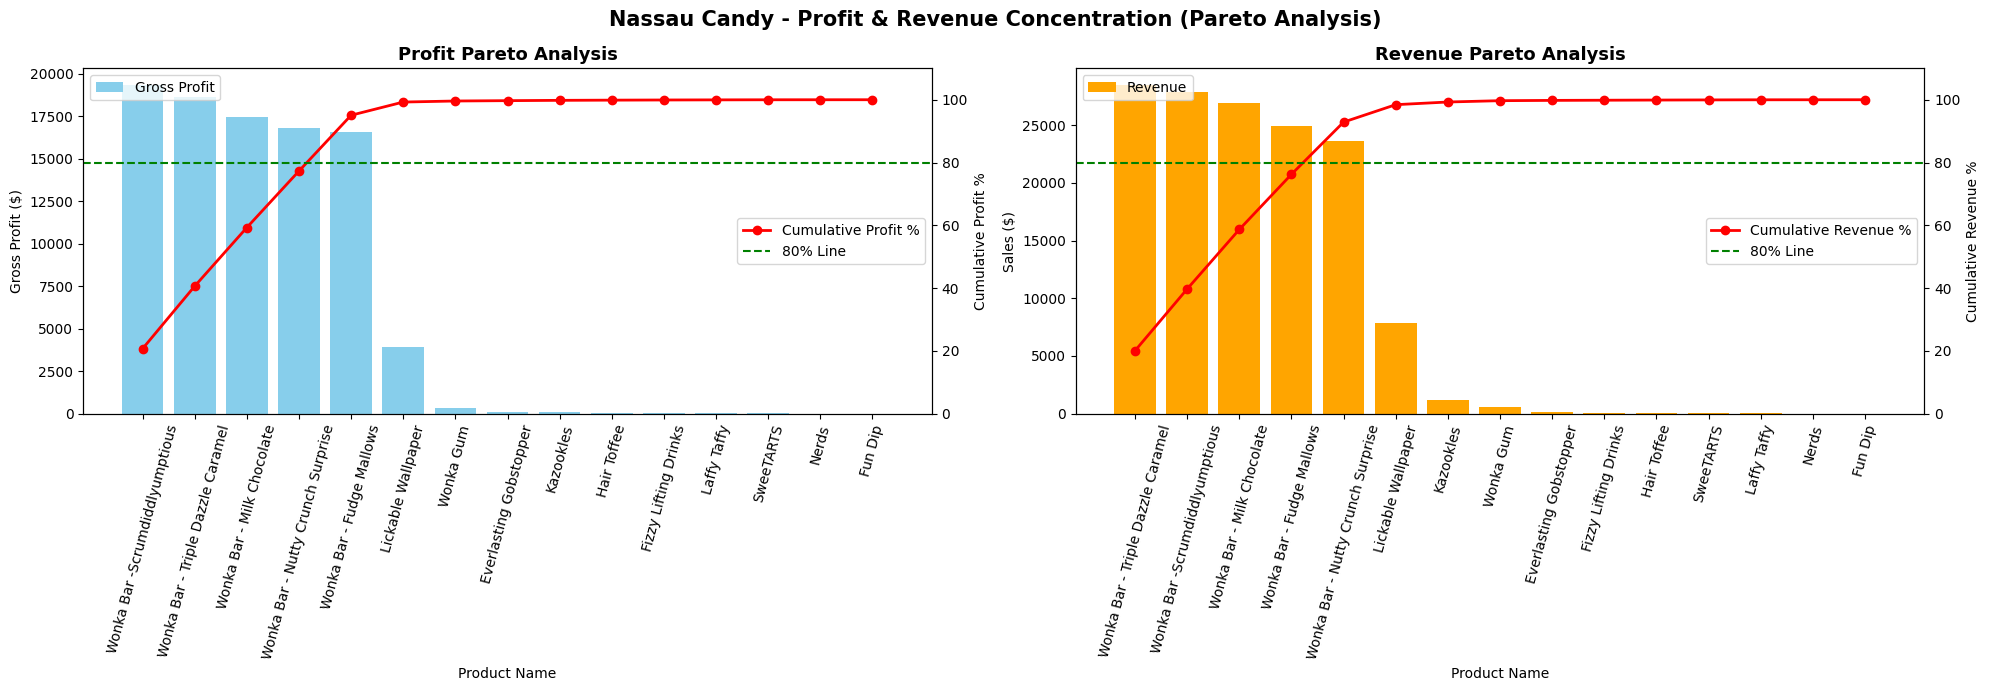

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Chart 1: Profit Pareto ---
axes[0].bar(
    pareto_profit["Product Name"],
    pareto_profit["Gross Profit"],
    color="skyblue",
    label="Gross Profit"
)

ax2 = axes[0].twinx()
ax2.plot(
    pareto_profit["Product Name"],
    pareto_profit["Cumulative_Profit_%"],
    color="red",
    marker="o",
    linewidth=2,
    label="Cumulative Profit %"
)
ax2.axhline(y=80, color="green", linestyle="--", label="80% Line")
ax2.set_ylabel("Cumulative Profit %")
ax2.set_ylim(0, 110)

axes[0].set_title("Profit Pareto Analysis", fontweight="bold", fontsize=13)
axes[0].set_ylabel("Gross Profit ($)")
axes[0].set_xlabel("Product Name")
axes[0].tick_params(axis='x', rotation=75)
axes[0].legend(loc="upper left")
ax2.legend(loc="center right")

# --- Chart 2: Revenue Pareto ---
axes[1].bar(
    pareto_revenue["Product Name"],
    pareto_revenue["Sales"],
    color="orange",
    label="Revenue"
)

ax3 = axes[1].twinx()
ax3.plot(
    pareto_revenue["Product Name"],
    pareto_revenue["Cumulative_Revenue_%"],
    color="red",
    marker="o",
    linewidth=2,
    label="Cumulative Revenue %"
)
ax3.axhline(y=80, color="green", linestyle="--", label="80% Line")
ax3.set_ylabel("Cumulative Revenue %")
ax3.set_ylim(0, 110)

axes[1].set_title("Revenue Pareto Analysis", fontweight="bold", fontsize=13)
axes[1].set_ylabel("Sales ($)")
axes[1].set_xlabel("Product Name")
axes[1].tick_params(axis='x', rotation=75)
axes[1].legend(loc="upper left")
ax3.legend(loc="center right")

plt.suptitle(
    "Nassau Candy - Profit & Revenue Concentration (Pareto Analysis)",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

## Cost vs Margin Diagnostics

This section analyzes the relationship between cost and sales to identify pricing inefficiencies, cost-heavy products, and margin risk flags.

In [14]:
# Cost vs Margin Diagnostics

# Margin Risk Flags
def margin_risk_flag(margin):
    if margin < 20:
        return "🚨 Critical Risk"
    elif margin < 40:
        return "⚠️ Watch Zone"
    elif margin < 60:
        return "🟡 Moderate"
    else:
        return "✅ Healthy"

product_summary["Margin_Risk_Flag"] = product_summary["Gross_Margin_%"].apply(margin_risk_flag)

# Display risk table
risk_table = product_summary[[
    "Product Name",
    "Division",
    "Sales",
    "Cost",
    "Gross_Margin_%",
    "Cost_to_Sales_Ratio",
    "Margin_Risk_Flag"
]].sort_values(by="Gross_Margin_%", ascending=True)

print("Cost & Margin Risk Analysis:")
display(risk_table)

Cost & Margin Risk Analysis:


,Product Name,Division,Sales,Cost,Gross_Margin_%,Cost_to_Sales_Ratio,Margin_Risk_Flag
4,Kazookles,Other,1205.75,1113.00,7.692308,92.307692,🚨 Critical Risk
2,Fun Dip,Sugar,12.00,7.20,40.000000,60.000000,🟡 Moderate
7,Nerds,Sugar,15.00,8.00,46.666667,53.333333,🟡 Moderate
8,SweeTARTS,Sugar,61.50,32.80,46.666667,53.333333,🟡 Moderate
6,Lickable Wallpaper,Other,7860.00,3930.00,50.000000,50.000000,🟡 Moderate
14,Wonka Gum,Other,597.50,286.80,52.000000,48.000000,🟡 Moderate
1,Fizzy Lifting Drinks,Sugar,78.75,31.50,60.000000,40.000000,✅ Healthy
5,Laffy Taffy,Sugar,53.73,20.25,62.311558,37.688442,✅ Healthy
10,Wonka Bar - Milk Chocolate,Chocolate,26867.75,9424.38,64.923077,35.076923,✅ Healthy
12,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,9874.80,65.333333,34.666667,✅ Healthy


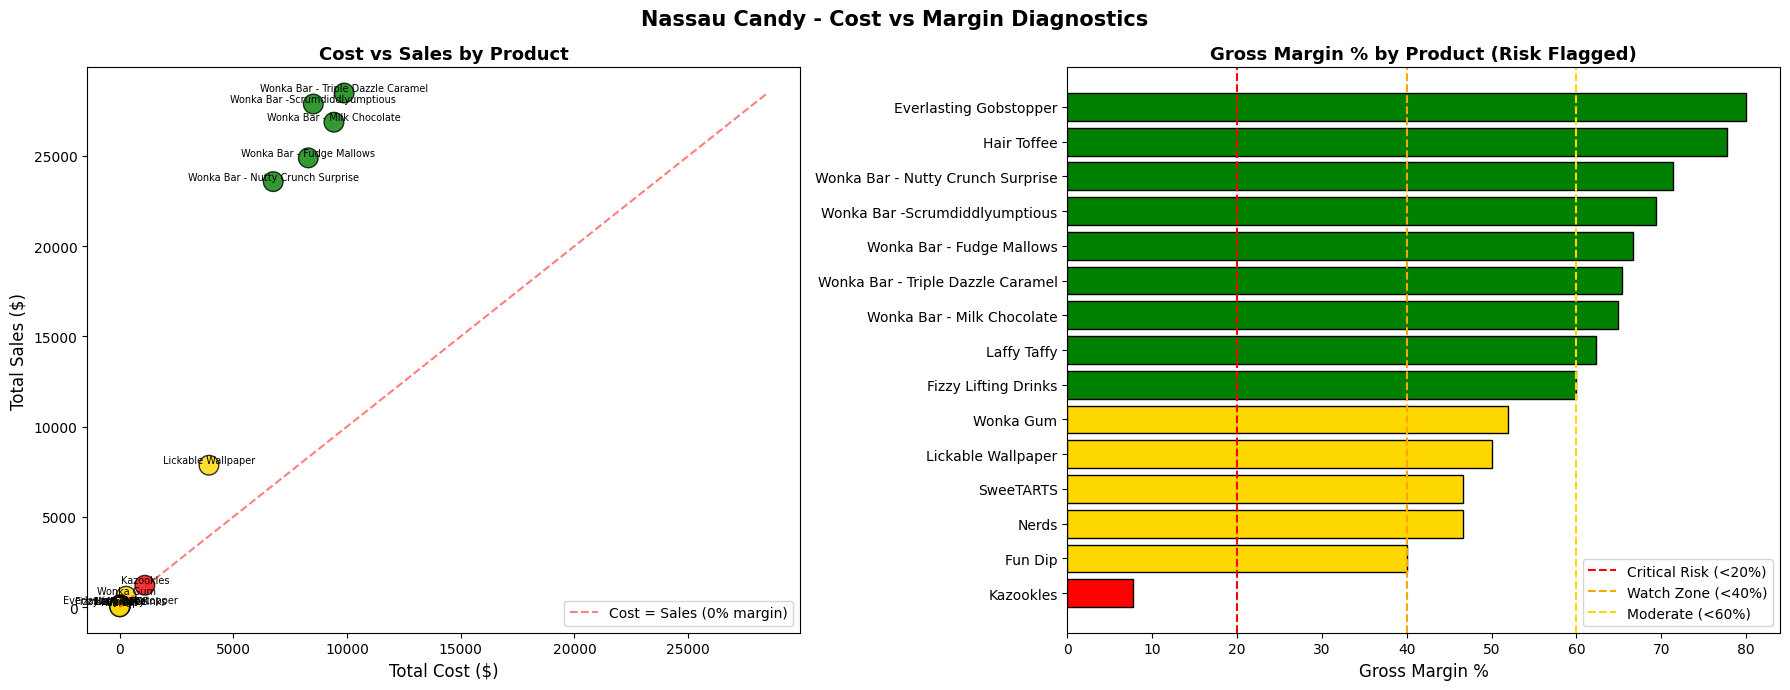


📋 Action Recommendations:

🚨 Reprice or Discontinue:


,Product Name,Gross_Margin_%,Cost_to_Sales_Ratio
4,Kazookles,7.692308,92.307692



⚠️ Review Pricing:


,Product Name,Gross_Margin_%,Cost_to_Sales_Ratio
6,Lickable Wallpaper,50.000000,50.000000
14,Wonka Gum,52.000000,48.000000
8,SweeTARTS,46.666667,53.333333
7,Nerds,46.666667,53.333333
2,Fun Dip,40.000000,60.000000


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Color mapping for risk flags
color_map = {
    "🚨 Critical Risk": "red",
    "⚠️ Watch Zone"  : "orange",
    "🟡 Moderate"    : "gold",
    "✅ Healthy"     : "green"
}

colors = product_summary["Margin_Risk_Flag"].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Chart 1: Cost vs Sales Scatter ---
axes[0].scatter(
    product_summary["Cost"],
    product_summary["Sales"],
    c=colors,
    s=200,
    edgecolors="black",
    alpha=0.8
)

for _, row in product_summary.iterrows():
    axes[0].annotate(
        row["Product Name"],
        (row["Cost"], row["Sales"]),
        fontsize=7,
        ha="center",
        va="bottom"
    )

# Diagonal line (Cost = Sales, margin = 0%)
max_val = max(product_summary["Sales"].max(), product_summary["Cost"].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label="Cost = Sales (0% margin)")

axes[0].set_xlabel("Total Cost ($)", fontsize=12)
axes[0].set_ylabel("Total Sales ($)", fontsize=12)
axes[0].set_title("Cost vs Sales by Product", fontweight="bold", fontsize=13)
axes[0].legend()

# --- Chart 2: Margin % Bar Chart with Risk Colors ---
sorted_df = product_summary.sort_values(by="Gross_Margin_%", ascending=True)
bar_colors = sorted_df["Margin_Risk_Flag"].map(color_map)

axes[1].barh(
    sorted_df["Product Name"],
    sorted_df["Gross_Margin_%"],
    color=bar_colors,
    edgecolor="black"
)

axes[1].axvline(x=20, color="red", linestyle="--", label="Critical Risk (<20%)")
axes[1].axvline(x=40, color="orange", linestyle="--", label="Watch Zone (<40%)")
axes[1].axvline(x=60, color="gold", linestyle="--", label="Moderate (<60%)")

axes[1].set_xlabel("Gross Margin %", fontsize=12)
axes[1].set_title("Gross Margin % by Product (Risk Flagged)", fontweight="bold", fontsize=13)
axes[1].legend(loc="lower right")

plt.suptitle(
    "Nassau Candy - Cost vs Margin Diagnostics",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

# Action Recommendations
print("\n📋 Action Recommendations:")
print("="*50)
print("\n🚨 Reprice or Discontinue:")
display(product_summary[product_summary["Margin_Risk_Flag"] == "🚨 Critical Risk"][["Product Name", "Gross_Margin_%", "Cost_to_Sales_Ratio"]])

print("\n⚠️ Review Pricing:")
display(product_summary[product_summary["Margin_Risk_Flag"] == "🟡 Moderate"][["Product Name", "Gross_Margin_%", "Cost_to_Sales_Ratio"]])

## Time Trend Analysis

This section analyzes how sales, gross profit, and gross margin have trended over time to identify seasonal patterns and performance changes.

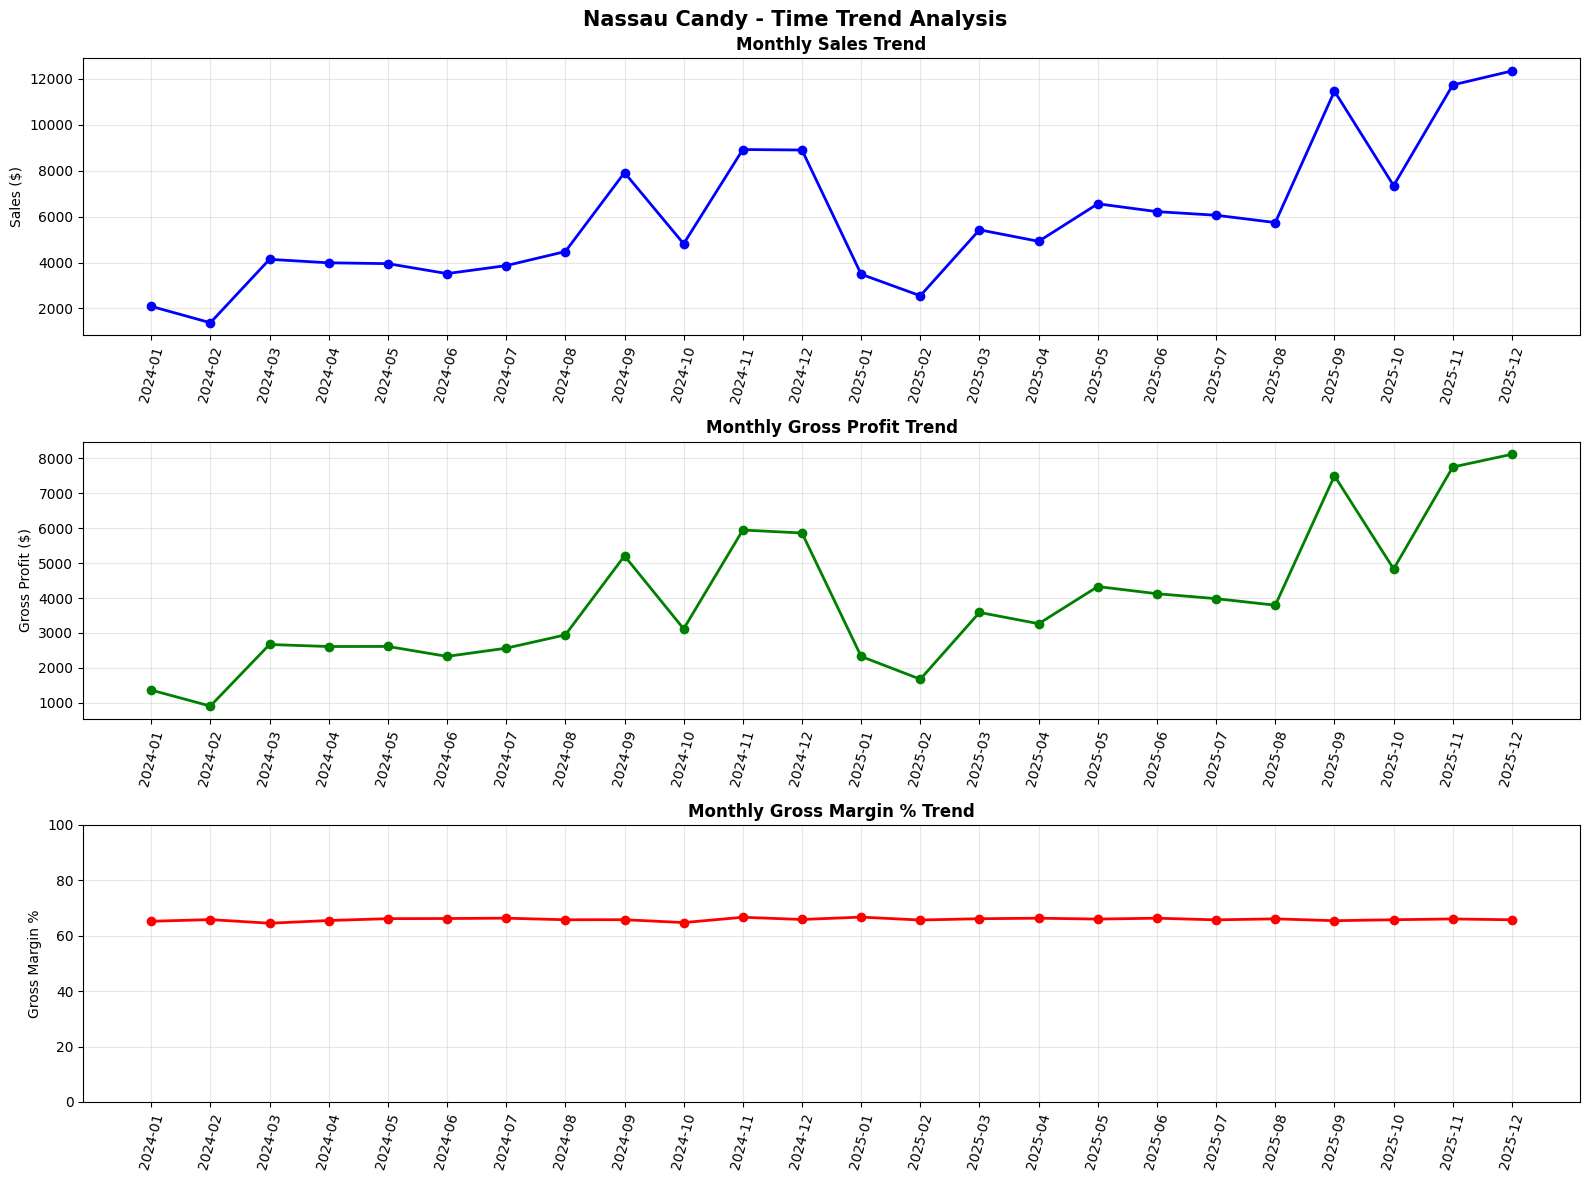

In [16]:
# Monthly Trend Analysis
monthly_trend = df.groupby(["Order_Year", "Order_Month"], as_index=False).agg({
    "Sales"       : "sum",
    "Gross Profit": "sum",
    "Units"       : "sum"
})

monthly_trend["Gross_Margin_%"] = (monthly_trend["Gross Profit"] / monthly_trend["Sales"]) * 100
monthly_trend["Month_Label"] = monthly_trend["Order_Year"].astype(str) + "-" + monthly_trend["Order_Month"].astype(str).str.zfill(2)
monthly_trend = monthly_trend.sort_values(by="Month_Label")

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Chart 1: Monthly Sales
axes[0].plot(monthly_trend["Month_Label"], monthly_trend["Sales"], 
             color="blue", marker="o", linewidth=2)
axes[0].set_title("Monthly Sales Trend", fontweight="bold")
axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis='x', rotation=75)
axes[0].grid(True, alpha=0.3)

# Chart 2: Monthly Gross Profit
axes[1].plot(monthly_trend["Month_Label"], monthly_trend["Gross Profit"],
             color="green", marker="o", linewidth=2)
axes[1].set_title("Monthly Gross Profit Trend", fontweight="bold")
axes[1].set_ylabel("Gross Profit ($)")
axes[1].tick_params(axis='x', rotation=75)
axes[1].grid(True, alpha=0.3)

# Chart 3: Monthly Margin %
axes[2].plot(monthly_trend["Month_Label"], monthly_trend["Gross_Margin_%"],
             color="red", marker="o", linewidth=2)
axes[2].set_title("Monthly Gross Margin % Trend", fontweight="bold")
axes[2].set_ylabel("Gross Margin %")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=75)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Nassau Candy - Time Trend Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## Key Insights & Business Recommendations

### 🔍 Key Insights:

- The Chocolate division dominates the business, contributing over 90% of total revenue and profit.
- Top 5 products contribute to more than 90% of total profit, indicating high dependency risk.
- Products like Kazookles have extremely low margins and high cost ratios, making them financially inefficient.
- Hidden gem products like Everlasting Gobstopper and Hair Toffee have very high margins but low sales.
- The Other Factory shows poor performance with very low margins and high costs.
- Overall gross margins are strong (~66%), but some products significantly drag performance down.

### 📊 Business Recommendations:

- Focus on expanding high-performing Chocolate products to maximize revenue and profit.
- Promote high-margin, low-sales products (e.g., Everlasting Gobstopper) through marketing and distribution.
- Review pricing strategy for moderate-margin products to improve profitability.
- Consider discontinuing or renegotiating costs for low-margin products like Kazookles.
- Investigate operational inefficiencies in The Other Factory.
- Diversify product portfolio to reduce dependency on a few top-performing products.